# Formative Assignment: Advanced Linear Algebra (PCA)
**Group / Peer Pair:** [Pair Number] &nbsp;|&nbsp; **Members:** [Names] &nbsp;|&nbsp; **GitHub repo:** [paste link here]

PCA implemented from scratch with **NumPy** (math) and **Matplotlib** (plots) only.

**Dataset:** [Name of Kaggle dataset + link] – Africanized data with missing values, at least 7 columns and at least one non-numeric column.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=150)

### Step 0: Locate and load the raw data (Kaggle)
Add your dataset through **Add Input** in the Kaggle notebook. It appears under `/kaggle/input/<dataset-name>/`. Set `DATA_PATH` below to your CSV (or leave `None` to list the available files).

In [2]:
DATA_PATH = '/kaggle/input/datasets/chirin/africa-economic-banking-and-systemic-crisis-data/african_crises.csv'

if not os.path.exists(DATA_PATH):
    print("❌ Path not found. Searching for the correct file path...")
    for root, _, files in os.walk('/kaggle/input'):
        for f in files:
            print(f"👉 Found correct path: {os.path.join(root, f)}")
    raise SystemExit('Copy one of the paths listed above, paste it into DATA_PATH, and re-run.')

# Load the data using your original NumPy logic
raw = np.genfromtxt(DATA_PATH, delimiter=',', dtype=str, encoding='utf-8',
                    autostrip=True, comments=None)
header, body = [str(h) for h in raw[0]], raw[1:]
print('Rows:', body.shape[0], '| Columns:', body.shape[1])
print('Columns:', list(header))
body[:5]

Rows: 1059 | Columns: 14
Columns: ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises', 'banking_crisis']


array([['1', 'DZA', 'Algeria', '1870', '1', '0.052264', '0', '0', '0', '3.441455696', '0', '0', '0', 'crisis'],
       ['1', 'DZA', 'Algeria', '1871', '0', '0.052798', '0', '0', '0', '14.14913958', '0', '0', '0', 'no_crisis'],
       ['1', 'DZA', 'Algeria', '1872', '0', '0.052274', '0', '0', '0', '-3.718592965', '0', '0', '0', 'no_crisis'],
       ['1', 'DZA', 'Algeria', '1873', '0', '0.05168', '0', '0', '0', '11.20389701', '0', '0', '0', 'no_crisis'],
       ['1', 'DZA', 'Algeria', '1874', '0', '0.051308', '0', '0', '0', '-3.848560701', '0', '0', '0', 'no_crisis']], dtype='<U31')

### Inspect column types and missing values
A column is treated as **numeric** if nearly all of its non-missing entries convert to numbers; otherwise it is **non-numeric** (text/categorical). Common missing markers (`''`, `NA`, `NaN`, `..`, `-`, `?`) become `NaN`.

In [3]:
MISSING = {'', 'na', 'n/a', 'nan', 'null', 'none', '-', '--', '..', '?'}

def to_float(col):
    out = np.full(len(col), np.nan)
    present = bad = 0
    for i, v in enumerate(col):
        s = v.strip().lower()
        if s in MISSING:
            continue
        present += 1
        try:
            out[i] = float(s.replace(',', ''))
        except ValueError:
            bad += 1
    return out, present, bad

numeric_cols, numeric_names, text_names = [], [], []
print(f"{'column':30s} {'type':12s} {'missing':>8s}")
for j, name in enumerate(header):
    vals, present, bad = to_float(body[:, j])
    is_numeric = present > 0 and bad / present < 0.05
    n_missing = int(np.isnan(vals).sum()) if is_numeric else int(sum(v.strip().lower() in MISSING for v in body[:, j]))
    print(f'{name:30s} {"numeric" if is_numeric else "NON-NUMERIC":12s} {n_missing:8d}')
    if is_numeric:
        numeric_cols.append(vals); numeric_names.append(name)
    else:
        text_names.append(name)

X_raw = np.column_stack(numeric_cols)
print('\nNon-numeric columns (excluded from PCA):', text_names)
print('Total NaN in numeric data:', int(np.isnan(X_raw).sum()))

column                         type          missing
case                           numeric             0
cc3                            NON-NUMERIC         0
country                        NON-NUMERIC         0
year                           numeric             0
systemic_crisis                numeric             0
exch_usd                       numeric             0
domestic_debt_in_default       numeric             0
sovereign_external_debt_default numeric             0
gdp_weighted_default           numeric             0
inflation_annual_cpi           numeric             0
independence                   numeric             0
currency_crises                numeric             0
inflation_crises               numeric             0
banking_crisis                 NON-NUMERIC         0

Non-numeric columns (excluded from PCA): ['cc3', 'country', 'banking_crisis']
Total NaN in numeric data: 0


### Step 1: Load and Standardize the Data
Cleaning first: drop columns you don't want as PCA features (IDs, years, binary flags – set `EXCLUDE`), drop all-NaN columns, then **impute** remaining NaNs with the column median (robust to outliers). Then standardize with the z-score formula from the image:

$$z = \frac{x - \mu}{\sigma}$$

In [4]:
EXCLUDE = []   # e.g. ['year', 'case'] – names of numeric columns that are identifiers, not features

keep = [k for k, n in enumerate(numeric_names) if n not in EXCLUDE and not np.all(np.isnan(X_raw[:, k]))]
feature_names = [numeric_names[k] for k in keep]
X = X_raw[:, keep]

# Median imputation (NumPy only)
col_medians = np.nanmedian(X, axis=0)
X = np.where(np.isnan(X), col_medians, X)

# Drop constant columns (std = 0 would divide by zero)
nonconst = X.std(axis=0, ddof=1) > 0
X = X[:, nonconst]
feature_names = [n for n, ok in zip(feature_names, nonconst) if ok]

print('Features used for PCA:', feature_names)
print('Data shape:', X.shape, '| NaNs left:', int(np.isnan(X).sum()))
if X.shape[1] < 7:
    print('WARNING: the assignment requires at least 7 columns.')

Features used for PCA: ['case', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises']
Data shape: (1059, 11) | NaNs left: 0


In [5]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.mean(axis=0)
std = X.std(axis=0, ddof=1)        # sample std, consistent with the (n-1) covariance below
standardized_data = (X - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.461 , -2.9158,  3.4501, -0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853],
       [-1.461 , -2.8859, -0.2896, -0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853],
       [-1.461 , -2.8561, -0.2896, -0.3865, -0.2031, -0.4248, -0.1469, -0.0309, -1.8615, -0.3779, -0.3853],
       [-1.461 , -2.8263, -0.2896, -0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853],
       [-1.461 , -2.7965, -0.2896, -0.3865, -0.2031, -0.4248, -0.1469, -0.0309, -1.8615, -0.3779, -0.3853]])

In [6]:
# Sanity check: every feature should now have mean ~0 and std ~1
print('Means:', standardized_data.mean(axis=0))
print('Stds :', standardized_data.std(axis=0, ddof=1))

Means: [ 0. -0.  0. -0.  0. -0. -0. -0. -0. -0.  0.]
Stds : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [7]:
# Step 3: Calculate the Covariance Matrix
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)   # data is already centred
print('Matches np.cov:', np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False)))
cov_matrix

Matches np.cov: True


array([[ 1.    ,  0.1156,  0.011 , -0.232 ,  0.1284, -0.0393, -0.033 ,  0.0448,  0.0219,  0.0953,  0.0064],
       [ 0.1156,  1.    ,  0.1975,  0.2488,  0.1368,  0.2719, -0.0547,  0.037 ,  0.4074,  0.1894,  0.0986],
       [ 0.011 ,  0.1975,  1.    ,  0.2027,  0.1222,  0.2499,  0.0053,  0.1065,  0.1471,  0.1128,  0.1726],
       [-0.232 ,  0.2488,  0.2027,  1.    ,  0.0053,  0.4229, -0.0407, -0.0119,  0.126 , -0.0565, -0.0638],
       [ 0.1284,  0.1368,  0.1222,  0.0053,  1.    ,  0.4648, -0.0299,  0.1518,  0.1091,  0.2276,  0.2244],
       [-0.0393,  0.2719,  0.2499,  0.4229,  0.4648,  1.    ,  0.3459,  0.0726,  0.2282,  0.1994,  0.1879],
       [-0.033 , -0.0547,  0.0053, -0.0407, -0.0299,  0.3459,  1.    , -0.0045,  0.0789,  0.017 ,  0.0176],
       [ 0.0448,  0.037 ,  0.1065, -0.0119,  0.1518,  0.0726, -0.0045,  1.    ,  0.0166,  0.0766,  0.0801],
       [ 0.0219,  0.4074,  0.1471,  0.126 ,  0.1091,  0.2282,  0.0789,  0.0166,  1.    ,  0.0864, -0.0225],
       [ 0.0953,  0.1894,  0

**Why do we compute a covariance matrix? (max 5 lines, at least 2 reasons)**

> *[Write this in your own words – the brief asks you to avoid AI-generated interpretations. Prompts: What does an off-diagonal entry tell you about two features? What does the matrix let us find (directions of maximum variance)? Why is it symmetric and why does that matter for eigendecomposition?]*

### Step 4: Perform Eigendecomposition
`np.linalg.eigh` is used because the covariance matrix is symmetric: it is faster, returns real eigenvalues and gives orthonormal eigenvectors.

In [8]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.2542, 0.4844, 0.577 , 0.702 , 0.8354, 0.8981, 1.0086, 1.1066, 1.2235, 1.5229, 2.3873]),
 array([[-0.0257, -0.3178,  0.0661,  0.3616,  0.4675,  0.1603,  0.1971,  0.4182,  0.4003, -0.3787, -0.0395],
        [-0.033 ,  0.6258,  0.3012,  0.2606, -0.1261, -0.0627, -0.1522,  0.0596,  0.4882,  0.1387, -0.3801],
        [-0.0274,  0.1294, -0.1939, -0.3328,  0.6945, -0.3846,  0.1063, -0.2879,  0.0603,  0.0705, -0.3179],
        [-0.4157, -0.3653, -0.0229,  0.4342,  0.0513,  0.1922,  0.0415, -0.3179, -0.0442,  0.541 , -0.2603],
        [-0.4149,  0.173 , -0.0334, -0.4038, -0.0974,  0.5731,  0.2848,  0.0357, -0.0948, -0.2602, -0.3698],
        [ 0.7145, -0.0494,  0.0023,  0.0876,  0.0467,  0.2459,  0.0924,  0.154 , -0.3219,  0.169 , -0.5023],
        [-0.3695,  0.1411,  0.0504,  0.1176,  0.0877, -0.3425, -0.0494,  0.6241, -0.5344,  0.1021, -0.1191],
        [ 0.0236, -0.0362,  0.0303,  0.1948, -0.3534, -0.4349,  0.7513, -0.1585, -0.0202, -0.1915, -0.1365],
        [-0.0212, -0.4753, -0.

### Step 5: Sort Principal Components
Sort eigenvectors by eigenvalue in descending order; the larger the eigenvalue, the more variance that component explains.

<a href='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?</a>

In [9]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]        # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices] # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-0.0395, -0.3787,  0.4003,  0.4182,  0.1971,  0.1603,  0.4675,  0.3616,  0.0661, -0.3178, -0.0257],
       [-0.3801,  0.1387,  0.4882,  0.0596, -0.1522, -0.0627, -0.1261,  0.2606,  0.3012,  0.6258, -0.033 ],
       [-0.3179,  0.0705,  0.0603, -0.2879,  0.1063, -0.3846,  0.6945, -0.3328, -0.1939,  0.1294, -0.0274],
       [-0.2603,  0.541 , -0.0442, -0.3179,  0.0415,  0.1922,  0.0513,  0.4342, -0.0229, -0.3653, -0.4157],
       [-0.3698, -0.2602, -0.0948,  0.0357,  0.2848,  0.5731, -0.0974, -0.4038, -0.0334,  0.173 , -0.4149],
       [-0.5023,  0.169 , -0.3219,  0.154 ,  0.0924,  0.2459,  0.0467,  0.0876,  0.0023, -0.0494,  0.7145],
       [-0.1191,  0.1021, -0.5344,  0.6241, -0.0494, -0.3425,  0.0877,  0.1176,  0.0504,  0.1411, -0.3695],
       [-0.1365, -0.1915, -0.0202, -0.1585,  0.7513, -0.4349, -0.3534,  0.1948,  0.0303, -0.0362,  0.0236],
       [-0.3045,  0.2209,  0.3906,  0.3275, -0.1115, -0.24  , -0.3164, -0.4468, -0.051 , -0.4753, -0.0212],
       [-0.3085, -0.4145, -0

  PC  eigenvalue  explained  cumulative
PC1       2.3873     21.70%      21.70%
PC2       1.5229     13.84%      35.55%
PC3       1.2235     11.12%      46.67%
PC4       1.1066     10.06%      56.73%
PC5       1.0086      9.17%      65.90%
PC6       0.8981      8.16%      74.06%
PC7       0.8354      7.59%      81.66%
PC8       0.7020      6.38%      88.04%
PC9       0.5770      5.25%      93.29%
PC10      0.4844      4.40%      97.69%
PC11      0.2542      2.31%     100.00%


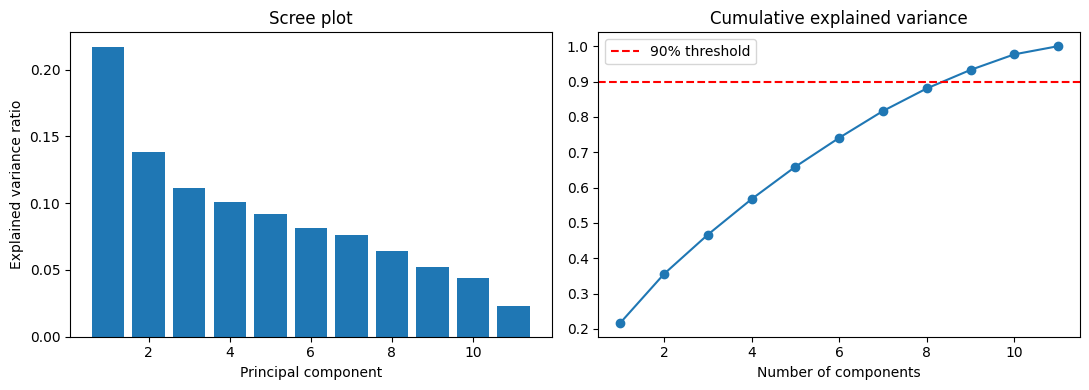

In [10]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':>4s} {'eigenvalue':>11s} {'explained':>10s} {'cumulative':>11s}")
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f'PC{i:<2d} {ev:11.4f} {r:10.2%} {c:11.2%}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
ax[0].set_title('Scree plot'); ax[0].set_xlabel('Principal component'); ax[0].set_ylabel('Explained variance ratio')
ax[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
ax[1].axhline(0.90, color='r', linestyle='--', label='90% threshold')
ax[1].set_title('Cumulative explained variance'); ax[1].set_xlabel('Number of components'); ax[1].legend()
plt.tight_layout(); plt.show()

### Step 6: Project Data onto Principal Components
**Task 2 – dynamic selection:** keep the smallest number of components whose cumulative explained variance reaches `VARIANCE_THRESHOLD`. Change the threshold and re-run to see the trade-off.

In [11]:
# Step 6: Project Data onto Principal Components
VARIANCE_THRESHOLD = 0.90
num_components = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1)  # Decide on the number of principal components to keep
num_components = min(num_components, len(sorted_eigenvalues))
print(f'Keeping {num_components} of {len(sorted_eigenvalues)} components '
      f'({cumulative_variance[num_components-1]:.2%} of variance retained)')

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]  # Project data onto the principal components
reduced_data[:5]

Keeping 9 of 11 components (93.29% of variance retained)


array([[ 1.2691,  0.062 , -2.1857, -2.2783,  0.8737, -1.0669,  2.7189, -1.8478, -1.5335],
       [ 2.4467, -0.1976, -2.3966, -1.1997,  0.4714,  0.3696,  0.1178, -0.5956, -0.7994],
       [ 2.4353, -0.1934, -2.382 , -1.1979,  0.4669,  0.3678,  0.1141, -0.5878, -0.7905],
       [ 2.424 , -0.1893, -2.3674, -1.1962,  0.4624,  0.3659,  0.1103, -0.58  , -0.7815],
       [ 2.4127, -0.1852, -2.3529, -1.1944,  0.4578,  0.364 ,  0.1066, -0.5723, -0.7725]])

In [12]:
# Which original features drive each kept component? (loadings)
for i in range(num_components):
    order = np.argsort(np.abs(sorted_eigenvectors[:, i]))[::-1]
    print(f'PC{i+1} ({explained_variance_ratio[i]:.1%}):',
          ', '.join(f'{feature_names[k]} ({sorted_eigenvectors[k, i]:+.2f})' for k in order[:4]))

PC1 (21.7%): sovereign_external_debt_default (-0.50), year (-0.38), domestic_debt_in_default (-0.37), systemic_crisis (-0.32)
PC2 (13.8%): exch_usd (+0.54), inflation_crises (-0.42), currency_crises (-0.41), case (-0.38)
PC3 (11.1%): gdp_weighted_default (-0.53), year (+0.49), case (+0.40), independence (+0.39)
PC4 (10.1%): gdp_weighted_default (+0.62), case (+0.42), independence (+0.33), exch_usd (-0.32)
PC5 (9.2%): inflation_annual_cpi (+0.75), currency_crises (-0.38), inflation_crises (-0.34), domestic_debt_in_default (+0.28)
PC6 (8.2%): domestic_debt_in_default (+0.57), inflation_annual_cpi (-0.43), systemic_crisis (-0.38), gdp_weighted_default (-0.34)
PC7 (7.6%): systemic_crisis (+0.69), case (+0.47), inflation_annual_cpi (-0.35), independence (-0.32)
PC8 (6.4%): independence (-0.45), exch_usd (+0.43), domestic_debt_in_default (-0.40), case (+0.36)
PC9 (5.2%): currency_crises (-0.67), inflation_crises (+0.64), year (+0.30), systemic_crisis (-0.19)


### Step 7: Output the Reduced Data

In [13]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1059, 9)


array([[ 1.2691,  0.062 , -2.1857, -2.2783,  0.8737, -1.0669,  2.7189, -1.8478, -1.5335],
       [ 2.4467, -0.1976, -2.3966, -1.1997,  0.4714,  0.3696,  0.1178, -0.5956, -0.7994],
       [ 2.4353, -0.1934, -2.382 , -1.1979,  0.4669,  0.3678,  0.1141, -0.5878, -0.7905],
       [ 2.424 , -0.1893, -2.3674, -1.1962,  0.4624,  0.3659,  0.1103, -0.58  , -0.7815],
       [ 2.4127, -0.1852, -2.3529, -1.1944,  0.4578,  0.364 ,  0.1066, -0.5723, -0.7725]])

### Step 8: Visualize Before and After PCA

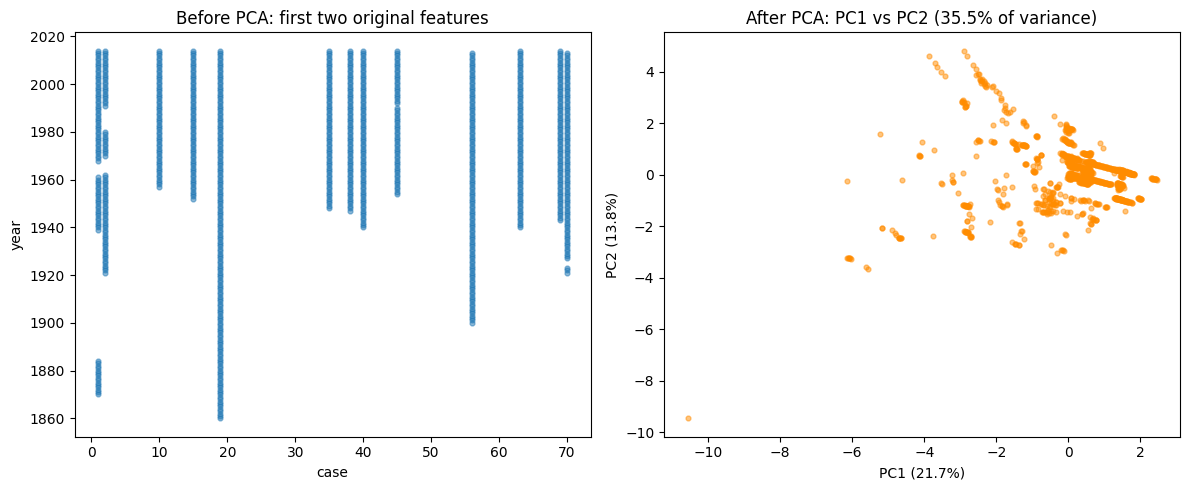

In [14]:
# Step 8: Visualize Before and After PCA
pcs_2d = standardized_data @ sorted_eigenvectors[:, :2]   # first two PCs for plotting

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
ax[0].scatter(X[:, 0], X[:, 1], alpha=0.5, s=12)
ax[0].set_title('Before PCA: first two original features')
ax[0].set_xlabel(feature_names[0]); ax[0].set_ylabel(feature_names[1])

# Plot reduced data after PCA
ax[1].scatter(pcs_2d[:, 0], pcs_2d[:, 1], alpha=0.5, s=12, color='darkorange')
ax[1].set_title(f'After PCA: PC1 vs PC2 ({cumulative_variance[1]:.1%} of variance)')
ax[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})'); ax[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')

plt.tight_layout(); plt.show()

### Written answers (max 5 lines each – write these yourselves, no AI-generated interpretation)

**1. Interpret the before/after PCA visual**
> *[Your answer. Prompts: Does the "before" plot show correlation/clusters/outliers? What is different on the PC axes? Are PC1 and PC2 uncorrelated? How much variance do they show together?]*

**2. Why did you select this number of principal components? What trade-offs?**
> *[Your answer. Cite `num_components`, the threshold and the cumulative variance printed in Step 6, and the scree plot elbow. Trade-off: fewer components = simpler/faster/less noise but more information discarded; more components = more faithful but less compression.]*

**3. What information is lost when reducing dimensions (for your dataset, e.g. "economic activity", "population pressure")?**
> *[Your answer. Use the loadings printed in Step 6 and the components you dropped: which features load mainly on the dropped PCs, and what real-world signal do they carry?]*

## Task 3: Performance optimisation and benchmarking
Compare a naive implementation (Python-loop covariance + general `np.linalg.eig`) with the optimised one (vectorised matrix product + `np.linalg.eigh`) on synthetic data of growing size, then show a **chunked** covariance that handles data too large to standardise in one go.

     rows  naive (s)   fast (s)  speed-up
     1000     0.0019     0.0005      3.9x
    10000     0.0054     0.0037      1.5x
   100000     0.0311     0.0211      1.5x
   500000     0.1567     0.1148      1.4x


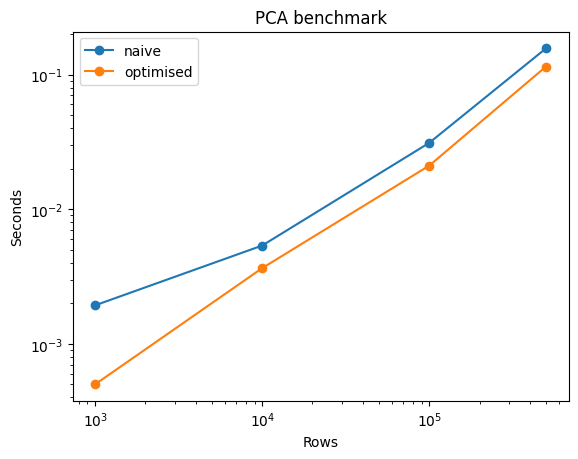

In [15]:
def pca_naive(data, k):
    n, p = data.shape
    Z = (data - data.mean(0)) / data.std(0, ddof=1)
    cov = np.empty((p, p))
    for i in range(p):                       # explicit loops – slow
        for j in range(p):
            cov[i, j] = np.dot(Z[:, i], Z[:, j]) / (n - 1)
    vals, vecs = np.linalg.eig(cov)
    idx = np.argsort(vals.real)[::-1]
    return Z @ vecs.real[:, idx[:k]]

def pca_fast(data, k):
    n = data.shape[0]
    Z = (data - data.mean(0)) / data.std(0, ddof=1)
    cov = (Z.T @ Z) / (n - 1)                # single BLAS matrix product
    vals, vecs = np.linalg.eigh(cov)         # symmetric solver
    return Z @ vecs[:, ::-1][:, :k]

p = X.shape[1]
rng = np.random.default_rng(42)
mix = rng.normal(size=(p, p))
sizes = [1_000, 10_000, 100_000, 500_000]
t_naive, t_fast = [], []

print(f"{'rows':>9s} {'naive (s)':>10s} {'fast (s)':>10s} {'speed-up':>9s}")
for n in sizes:
    data = rng.normal(size=(n, p)) @ mix
    t0 = time.perf_counter(); a = pca_naive(data, 2); t1 = time.perf_counter()
    b = pca_fast(data, 2);    t2 = time.perf_counter()
    t_naive.append(t1 - t0); t_fast.append(t2 - t1)
    # Same subspace up to sign: compare absolute values
    assert np.allclose(np.abs(a), np.abs(b), atol=1e-6)
    print(f'{n:9d} {t1-t0:10.4f} {t2-t1:10.4f} {(t1-t0)/(t2-t1):8.1f}x')

plt.plot(sizes, t_naive, marker='o', label='naive')
plt.plot(sizes, t_fast, marker='o', label='optimised')
plt.xscale('log'); plt.yscale('log'); plt.xlabel('Rows'); plt.ylabel('Seconds'); plt.legend()
plt.title('PCA benchmark'); plt.show()

In [16]:
def chunked_covariance(data, chunk=50_000):
    # Covariance of standardised data without holding a full standardised copy in memory.
    n, p = data.shape
    mean = np.zeros(p)
    for s in range(0, n, chunk):
        mean += data[s:s+chunk].sum(0)
    mean /= n
    sq = np.zeros(p)
    for s in range(0, n, chunk):
        sq += ((data[s:s+chunk] - mean) ** 2).sum(0)
    std = np.sqrt(sq / (n - 1))
    cov = np.zeros((p, p))
    for s in range(0, n, chunk):
        Zc = (data[s:s+chunk] - mean) / std
        cov += Zc.T @ Zc
    return cov / (n - 1)

big = rng.normal(size=(500_000, p)) @ mix
t0 = time.perf_counter(); cov_chunked = chunked_covariance(big); t1 = time.perf_counter()
Zb = (big - big.mean(0)) / big.std(0, ddof=1)
print('Chunked matches full computation:', np.allclose(cov_chunked, (Zb.T @ Zb) / (len(big) - 1)))
print(f'Chunked covariance on {big.shape[0]:,} rows: {t1-t0:.3f}s')

Chunked matches full computation: True
Chunked covariance on 500,000 rows: 0.077s


### Submission checklist
- [ ] Run all cells so every output is visible
- [ ] Replace the placeholders (pair number, names, dataset link, GitHub link) and write the three written answers plus the covariance paragraph
- [ ] GitHub repo contains: notebook, data (CSV), task sheet PDF
- [ ] Combined PDF: notebook PDF (with repo link) + task sheet PDF